## O que é o BERT?

BERT (introduzido neste [artigo](https://arxiv.org/abs/1810.04805)) significa Representações de Codificadores Bidirecionais a partir de Transformers. Se você não sabe o que a maioria desses termos significa – você veio ao lugar certo! Vamos destrinchar as ideias principais:

- **Bidirecional** – Para entender o texto, é preciso olhar para trás (às palavras anteriores) e para frente (às palavras seguintes).
- **Transformers** – O artigo [Attention Is All You Need](https://arxiv.org/abs/1706.03762) apresentou o modelo Transformer. O Transformer lê sequências inteiras de tokens de uma vez. Em certo sentido, o modelo é não-direcional, enquanto LSTMs leem sequencialmente (da esquerda para a direita ou vice-versa). O mecanismo de atenção permite aprender relações contextuais entre palavras (por exemplo, o pronome `his` em uma frase se refere a Jim).
- **Embeddings contextuais (pré-treinados)** – O artigo [ELMO](https://arxiv.org/abs/1802.05365v2) introduziu uma forma de codificar palavras com base em seu significado/contexto. Por exemplo, "nails" pode ter múltiplos significados – unhas (de mãos/pés) e pregos de metal.

BERT foi treinado mascarando 15% dos tokens com o objetivo de adivinhá-los. Um objetivo adicional foi prever a próxima sentença. Vamos ver exemplos dessas tarefas:

### Modelagem de Linguagem Mascarada (Masked LM)

O objetivo desta tarefa é adivinhar os tokens mascarados. Vamos ver um exemplo, sem complicar desnecessariamente:

> That's `[mask]` she `[mask]` -> That's what she said

### Previsão da Próxima Sentença (NSP)

Dado um par de duas sentenças, a tarefa é indicar se a segunda segue ou não a primeira (classificação binária). Vamos continuar com o exemplo:

*Entrada* = `[CLS]` That's `[mask]` she `[mask]`. [SEP] Hahaha, nice! [SEP]  
*Rótulo* = *IsNext*

*Entrada* = `[CLS]` That's `[mask]` she `[mask]`. [SEP] Dwight, you ignorant `[mask]`! [SEP]  
*Rótulo* = *NotNext*

O corpus de treinamento foi composto por dois conjuntos de dados: [Toronto Book Corpus](https://arxiv.org/abs/1506.06724) (800M de palavras) e a Wikipédia em inglês (2,500M de palavras). Enquanto o Transformer original possui um codificador (para ler a entrada) e um decodificador (que faz a predição), o BERT utiliza apenas o decodificador.

BERT é simplesmente uma pilha pré-treinada de Codificadores Transformer. Quantos codificadores? Temos duas versões – com 12 (BERT base) e 24 (BERT Large).

### Isso é Útil na Prática?

O artigo do BERT foi lançado juntamente com o [código-fonte](https://github.com/google-research/bert) e modelos pré-treinados.

A melhor parte é que você pode fazer Transfer Learning (graças às ideias do Transformer da OpenAI) com o BERT para muitas tarefas de PLN – Classificação, Question Answering, Reconhecimento de Entidades, etc. Você pode treinar com pequenas quantidades de dados e alcançar um desempenho excelente!

## CUDA

Vamos verificar a disponibilidade de executar com CUDA.

In [109]:
!nvidia-smi

Tue Apr  8 22:25:42 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.94                 Driver Version: 560.94         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060      WDDM  |   00000000:01:00.0 Off |                  N/A |
|  0%   37C    P8             15W /  170W |    7670MiB /  12288MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Setup

Precisaremos [da biblioteca Transformers](https://huggingface.co/transformers/) da Hugging Face:

In [110]:
!pip install -r requirements.txt

In [111]:
%reload_ext watermark
%watermark -v -p numpy,pandas,torch,transformers

Python implementation: CPython
Python version       : 3.12.4
IPython version      : 9.0.2

numpy       : 2.2.4
pandas      : 2.2.3
torch       : 2.5.1+cu121
transformers: 4.50.3



#### Configs

In [112]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn.functional as F
import matplotlib.pyplot as plt

from pylab import rcParams
from torch import nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from textwrap import wrap
from collections import defaultdict
from transformers import BertModel, BertTokenizer, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

SCORE_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02"]
SENTIMENT_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00"]

rcParams['figure.figsize'] = 12, 8

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

#### Exports

Carregamos o conjunto de dados de avaliações de aplicativos do Google Play, que reunimos na parte anterior:

In [113]:
df = pd.read_csv("data/preview.csv")
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,sortOrder,appId
0,c51ee54a-9298-41e8-88f2-7affcd7ec6c0,Hernan Fonseca,https://play-lh.googleusercontent.com/a-/ALV-U...,"Para mim, pedir pelo iFood só me traz uma cert...",1,13,10.64.0,2025-04-05 13:32:53,NaN,NaN,10.64.0,most_relevant,br.com.brainweb.ifood
1,4b835174-dc00-4df3-9311-959ceaba407b,Juliano,https://play-lh.googleusercontent.com/a-/ALV-U...,"Propaganda enganosa, descontos falsos, preços ...",1,46,10.64.0,2025-04-01 12:18:34,NaN,NaN,10.64.0,most_relevant,br.com.brainweb.ifood
2,00a76c33-93f8-4d82-ab4d-ef7ca9936add,Vênus Lilith,https://play-lh.googleusercontent.com/a-/ALV-U...,Não consigo utilizar a opção de pagamento na e...,1,56,10.62.0,2025-03-28 08:28:53,NaN,NaN,10.62.0,most_relevant,br.com.brainweb.ifood
3,eeda662b-a7c1-477f-831a-20a138cf09e0,Suelen Mantovani,https://play-lh.googleusercontent.com/a-/ALV-U...,"Tinha que ter a opção 0 estrela, aplicativo se...",1,5,10.64.0,2025-04-05 19:27:25,NaN,NaN,10.64.0,most_relevant,br.com.brainweb.ifood
4,b50547f5-ada0-4b18-b4e2-c382d1772288,Yanna Dias,https://play-lh.googleusercontent.com/a-/ALV-U...,O Ifood tem várias falhas no sistema! muitas v...,1,5,10.63.0,2025-04-04 20:25:39,NaN,NaN,10.63.0,most_relevant,br.com.brainweb.ifood


In [114]:
df.shape

(9400, 13)

Temos cerca de 11 mil exemplos. Vamos verificar se há valores faltantes:


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9400 entries, 0 to 9399
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              9400 non-null   object
 1   userName              9400 non-null   object
 2   userImage             9400 non-null   object
 3   content               9400 non-null   object
 4   score                 9400 non-null   int64 
 5   thumbsUpCount         9400 non-null   int64 
 6   reviewCreatedVersion  8410 non-null   object
 7   at                    9400 non-null   object
 8   replyContent          1966 non-null   object
 9   repliedAt             1966 non-null   object
 10  appVersion            8410 non-null   object
 11  sortOrder             9400 non-null   object
 12  appId                 9400 non-null   object
dtypes: int64(2), object(11)
memory usage: 954.8+ KB


Ótimo, sem valores faltantes nos textos de pontuação e revisão! Temos desequilíbrio de classes?

C:\Users\charl\AppData\Local\Temp\ipykernel_2964\1142703018.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df.score, palette=SCORE_COLORS_PALETTE)


Text(0.5, 0, 'review score')

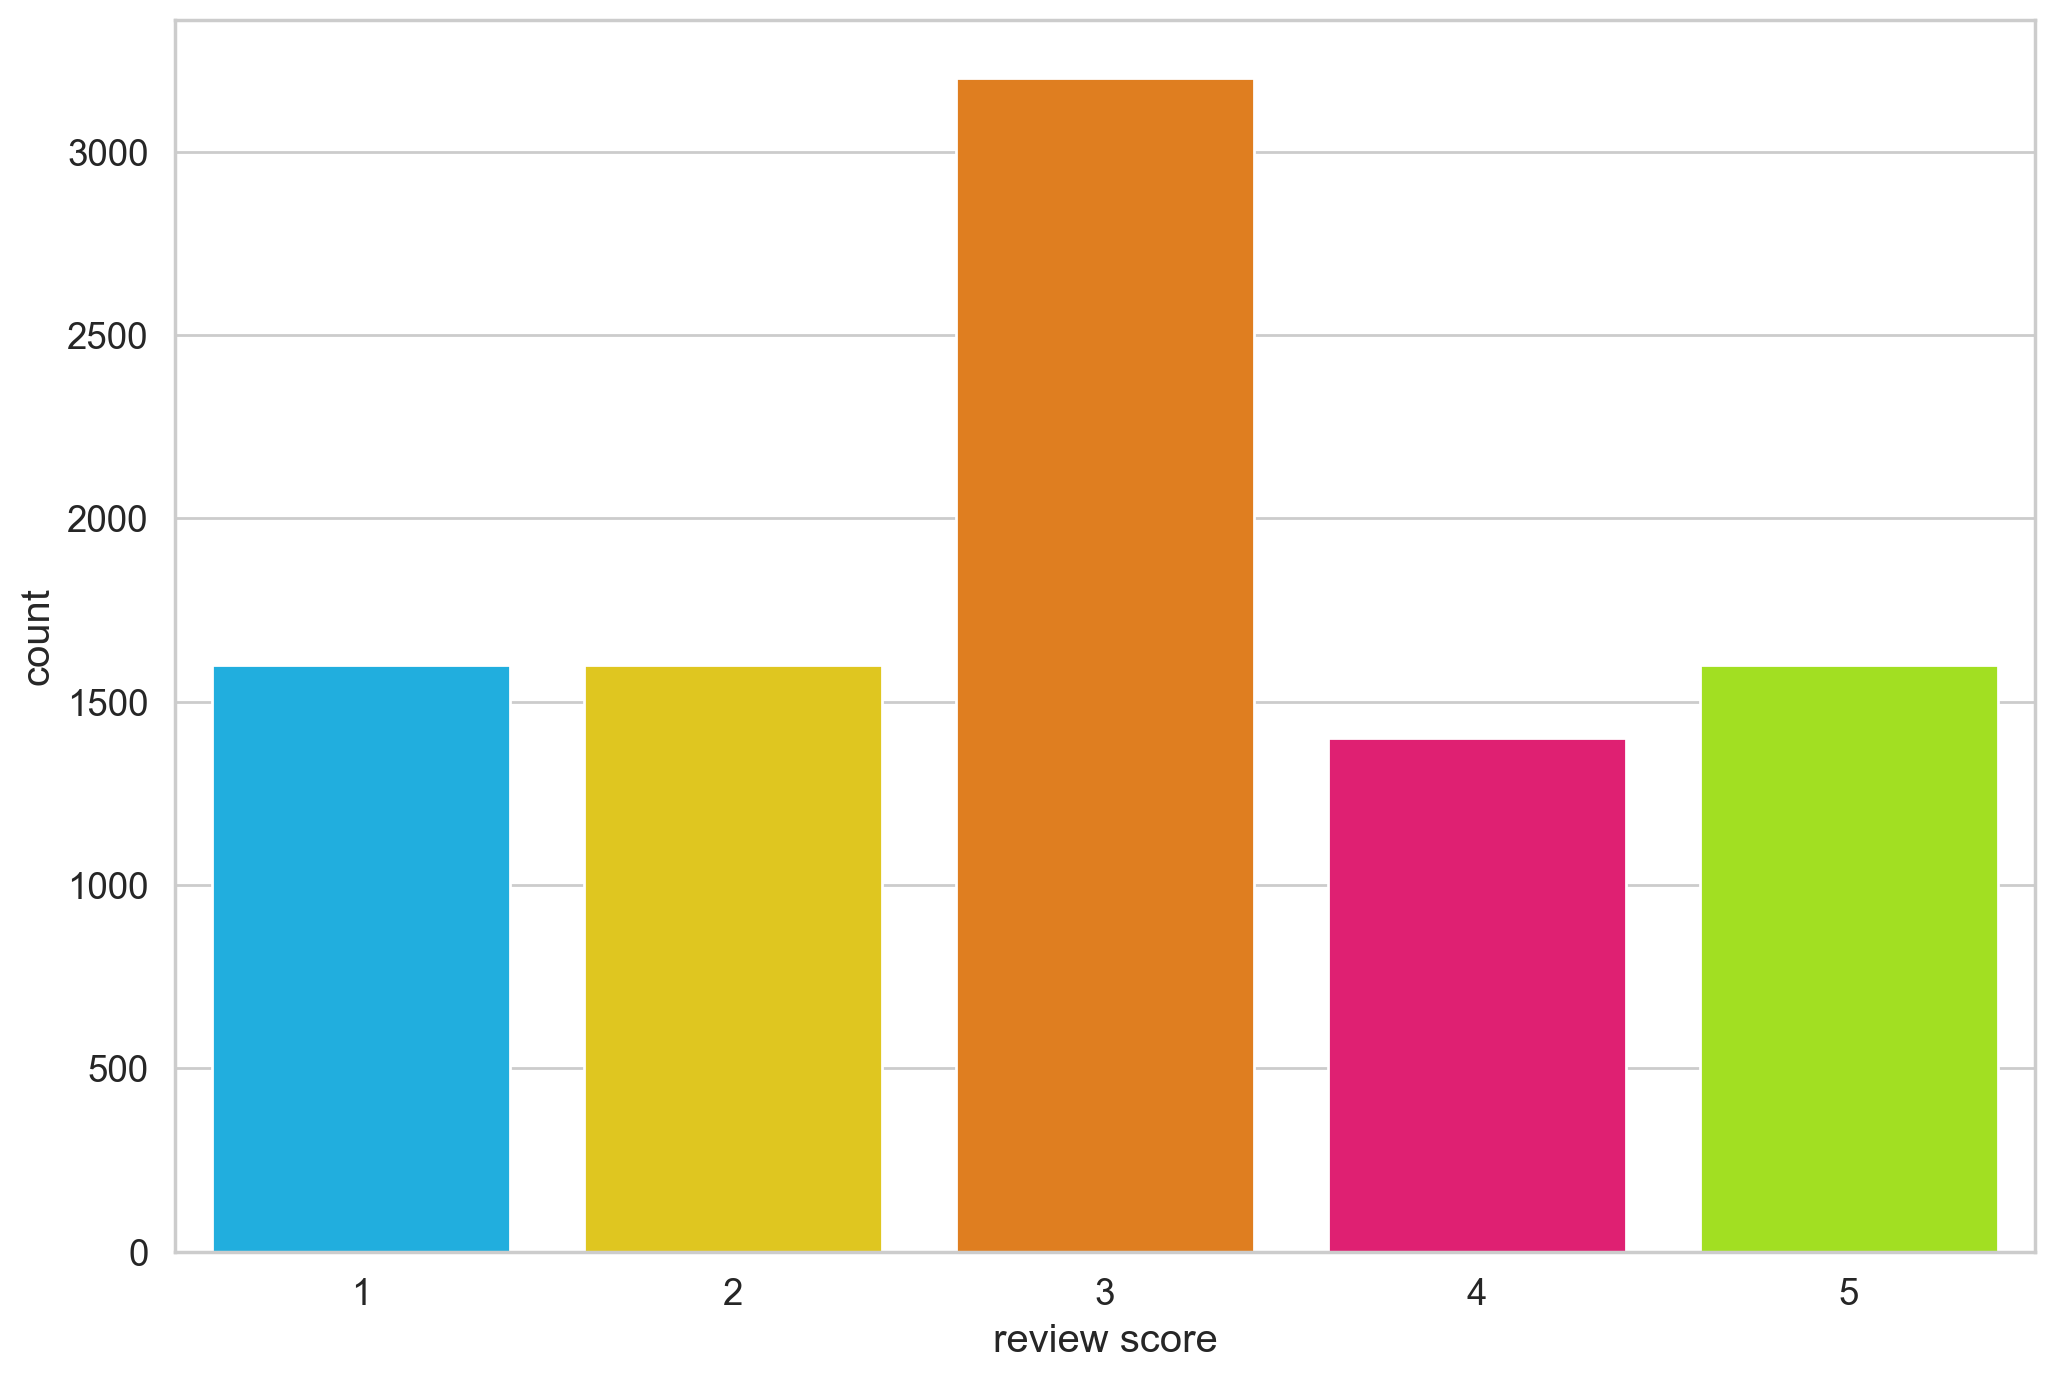

In [116]:
sns.countplot(x=df.score, palette=SCORE_COLORS_PALETTE)
plt.xlabel('review score')

Isso é muito desequilibrado, mas está tudo bem. Vamos converter o conjunto de dados em sentimento negativo, neutro e positivo:

In [117]:
def to_sentiment(rating):
  rating = int(rating)
  if rating <= 2:
    return 0
  elif rating == 3:
    return 1
  else:
    return 2

df['sentiment'] = df.score.apply(to_sentiment)

In [118]:
class_names = ['negative', 'neutral', 'positive']

C:\Users\charl\AppData\Local\Temp\ipykernel_2964\677087531.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df.sentiment, palette=SENTIMENT_COLORS_PALETTE)
C:\Users\charl\AppData\Local\Temp\ipykernel_2964\677087531.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names)


[Text(0, 0, 'negative'), Text(1, 0, 'neutral'), Text(2, 0, 'positive')]

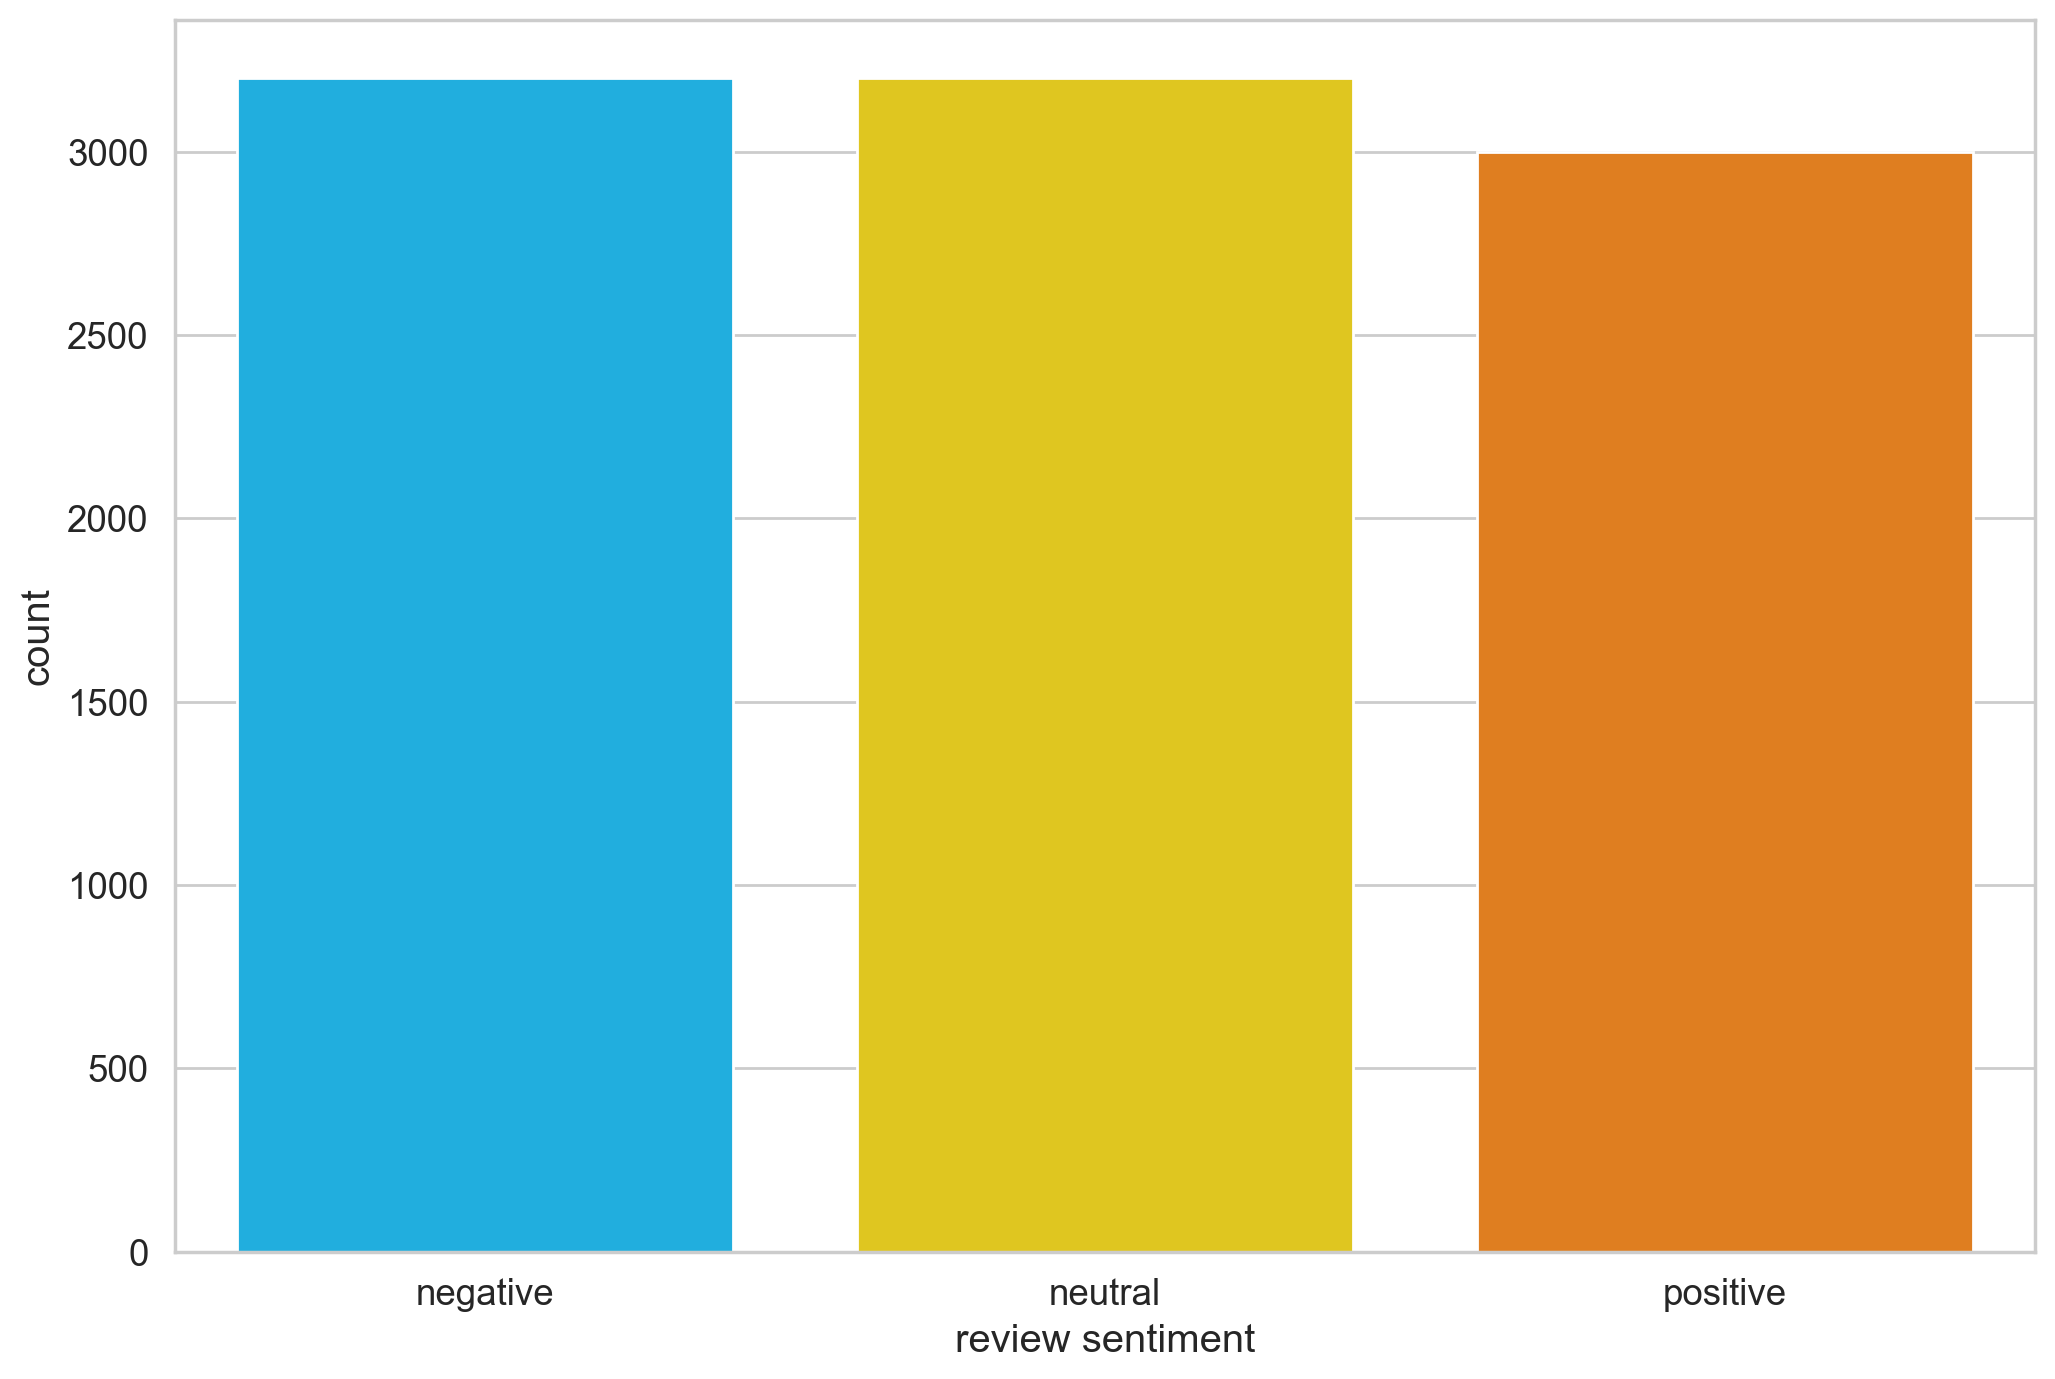

In [119]:
ax = sns.countplot(x=df.sentiment, palette=SENTIMENT_COLORS_PALETTE)
plt.xlabel('review sentiment')
ax.set_xticklabels(class_names)

O equilíbrio foi (em grande parte) restaurado.

## Pré-processamento

Você já deve saber que os modelos de Machine Learning não funcionam com texto bruto. Você precisa converter texto em números (de algum tipo). O BERT requer ainda mais atenção (boa, certo?). Aqui estão os requisitos:

- Adicione tokens especiais para separar frases e faça a classificação
- Passe sequências de comprimento constante (introduza preenchimento)
- Crie uma matriz de 0s (token de preenchimento) e 1s (token real) chamada *máscara de atenção*

A biblioteca Transformers fornece (você adivinhou) uma ampla variedade de modelos Transformers (incluindo BERT). Ela funciona com TensorFlow e PyTorch! Ela também inclui tokenizadores pré-construídos que fazem o trabalho pesado para nós!

In [120]:
PRE_TRAINED_MODEL_NAME = 'neuralmind/bert-base-portuguese-cased'

https://huggingface.co/neuralmind/bert-base-portuguese-cased

https://github.com/neuralmind-ai/portuguese-bert

> Você pode usar uma versão com e sem caixa de BERT e tokenizer. Eu experimentei ambos. A versão com caixa funciona melhor. Intuitivamente, isso faz sentido, já que "RUIM" pode transmitir mais sentimento do que "ruim".

Vamos carregar um [BertTokenizer](https://huggingface.co/transformers/model_doc/bert.html#berttokenizer) pré-treinado:

In [121]:
tokenizer = BertTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)

Usaremos este texto para entender o processo de tokenização:

In [122]:
sample_txt = 'Qual foi a última vez que saí de casa? Estou preso em casa por 2 semanas.'

Algumas operações básicas podem converter o texto em tokens e tokens em inteiros únicos (ids):

In [123]:
tokens = tokenizer.tokenize(sample_txt)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print(f' Sentence: {sample_txt}')
print(f'   Tokens: {tokens}')
print(f'Token IDs: {token_ids}')

 Sentence: Qual foi a última vez que saí de casa? Estou preso em casa por 2 semanas.
   Tokens: ['Qual', 'foi', 'a', 'última', 'vez', 'que', 'sa', '##í', 'de', 'casa', '?', 'Est', '##ou', 'preso', 'em', 'casa', 'por', '2', 'semanas', '.']
Token IDs: [13082, 262, 123, 2338, 576, 179, 629, 22306, 125, 1105, 136, 9009, 203, 5139, 173, 1105, 240, 245, 3765, 119]


### Special Tokens

`[SEP]` - marcador para o final de uma frase

In [124]:
tokenizer.sep_token, tokenizer.sep_token_id

('[SEP]', 102)

`[CLS]` - devemos adicionar este token ao início de cada frase, para que BERT saiba que estamos fazendo uma classificação

In [125]:
tokenizer.cls_token, tokenizer.cls_token_id

('[CLS]', 101)

Há também um token especial para preenchimento:

In [126]:
tokenizer.pad_token, tokenizer.pad_token_id

('[PAD]', 0)

BERT entende tokens que estavam no conjunto de treinamento. Todo o resto pode ser codificado usando o token `[UNK]` (desconhecido):

In [127]:
tokenizer.unk_token, tokenizer.unk_token_id

('[UNK]', 100)

Todo esse trabalho pode ser feito usando o método [`encode_plus()`](https://huggingface.co/transformers/main_classes/tokenizer.html#transformers.PreTrainedTokenizer.encode_plus):

In [128]:
encoding = tokenizer.encode_plus(
  sample_txt,
  max_length=32,
  add_special_tokens=True, # Add '[CLS]' and '[SEP]'
  return_token_type_ids=False,
  #padding='longest',
  pad_to_max_length=True,
  return_attention_mask=True,
  return_tensors='pt',  # Return PyTorch tensors
)

encoding.keys()

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
d:\Visual Code\Classification\venv\Lib\site-packages\transformers\tokenization_utils_base.py:2700: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


dict_keys(['input_ids', 'attention_mask'])

Os IDs de token agora são armazenados em um Tensor e preenchidos com um comprimento de 32:

In [129]:
print(len(encoding['input_ids'][0]))
encoding['input_ids'][0]

32


tensor([  101, 13082,   262,   123,  2338,   576,   179,   629, 22306,   125,
         1105,   136,  9009,   203,  5139,   173,  1105,   240,   245,  3765,
          119,   102,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0])

A máscara de atenção tem o mesmo comprimento:

In [130]:
print(len(encoding['attention_mask'][0]))
encoding['attention_mask']

32


tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])

Podemos inverter a tokenização para dar uma olhada nos tokens especiais:

In [131]:
tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])

['[CLS]',
 'Qual',
 'foi',
 'a',
 'última',
 'vez',
 'que',
 'sa',
 '##í',
 'de',
 'casa',
 '?',
 'Est',
 '##ou',
 'preso',
 'em',
 'casa',
 'por',
 '2',
 'semanas',
 '.',
 '[SEP]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]']

### Escolhendo o comprimento da sequência

BERT trabalha com sequências de comprimento fixo. Usaremos uma estratégia simples para escolher o comprimento máximo. Vamos armazenar o comprimento do token de cada revisão:

In [132]:
token_lens = []

for txt in df.content:
  tokens = tokenizer.encode(txt, max_length=512)
  token_lens.append(len(tokens))

e plotar a distribuição:

C:\Users\charl\AppData\Local\Temp\ipykernel_2964\1971794795.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(token_lens)


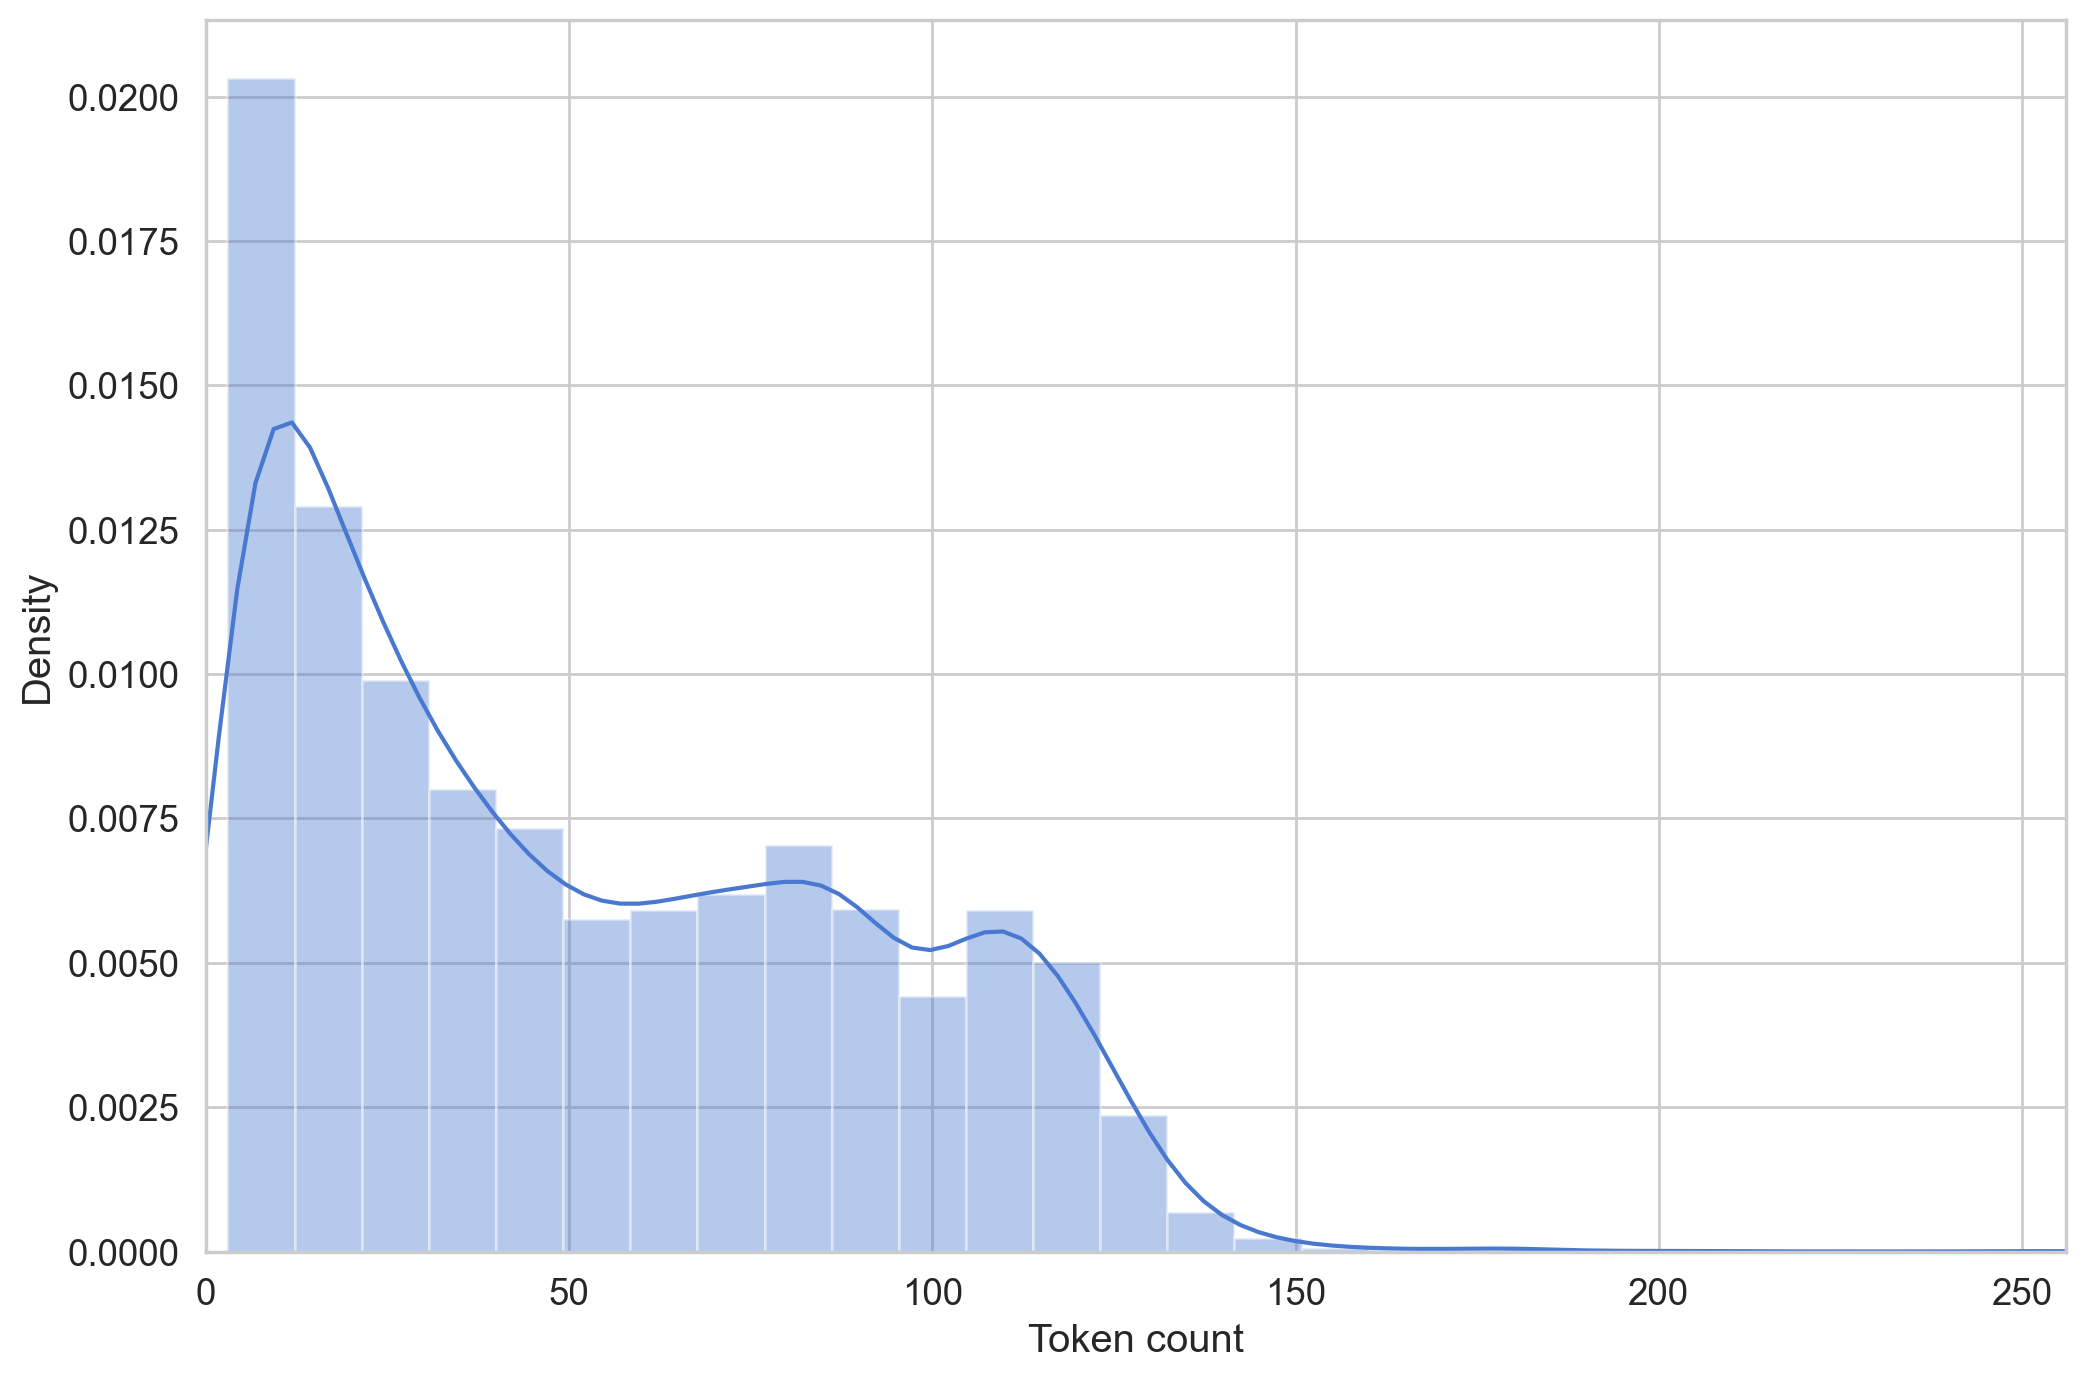

In [133]:
sns.distplot(token_lens)
plt.xlim([0, 256]);
plt.xlabel('Token count');

A maioria das análises parece conter menos de 128 tokens, mas vamos ser cautelosos e escolher um tamanho máximo de 160.

In [134]:
MAX_LEN = 160

Temos todos os blocos de construção necessários para criar um conjunto de dados PyTorch. Vamos lá:

In [135]:
class GPReviewDataset(Dataset):

  def __init__(self, reviews, targets, tokenizer, max_len):
    self.reviews = reviews
    self.targets = targets
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    return len(self.reviews)

  def __getitem__(self, item):
    review = str(self.reviews[item])
    target = self.targets[item]

    encoding = self.tokenizer.encode_plus(
      review,
      add_special_tokens=True,
      max_length=self.max_len,
      return_token_type_ids=False,
      #padding='longest',
      pad_to_max_length=True,
      return_attention_mask=True,
      return_tensors='pt',
    )

    return {
      'review_text': review,
      'input_ids': encoding['input_ids'].flatten(),
      'attention_mask': encoding['attention_mask'].flatten(),
      'targets': torch.tensor(target, dtype=torch.long)
    }

O tokenizer está fazendo a maior parte do trabalho pesado para nós. Também retornamos os textos de revisão, então será mais fácil avaliar as previsões do nosso modelo. Vamos dividir os dados:

In [136]:
df_train, df_test = train_test_split(df, test_size=0.1, random_state=RANDOM_SEED)
df_val, df_test = train_test_split(df_test, test_size=0.5, random_state=RANDOM_SEED)

In [137]:
df_train.shape, df_val.shape, df_test.shape

((8460, 14), (470, 14), (470, 14))

Também precisamos criar alguns carregadores de dados. Aqui está uma função auxiliar para fazer isso:

* para Windows "num_workers=0"

In [138]:
def create_data_loader(df, tokenizer, max_len, batch_size):
  ds = GPReviewDataset(
    reviews=df.content.to_numpy(),
    targets=df.sentiment.to_numpy(),
    tokenizer=tokenizer,
    max_len=max_len
  )

  return DataLoader(
    ds,
    batch_size=batch_size,
    num_workers=0
  )

In [139]:
BATCH_SIZE = 16

train_data_loader = create_data_loader(df_train, tokenizer, MAX_LEN, BATCH_SIZE)
val_data_loader = create_data_loader(df_val, tokenizer, MAX_LEN, BATCH_SIZE)
test_data_loader = create_data_loader(df_test, tokenizer, MAX_LEN, BATCH_SIZE)

Vamos dar uma olhada em um lote de exemplo do nosso carregador de dados de treinamento:

In [140]:
len(train_data_loader)

529

In [141]:
data = next(iter(train_data_loader))
data.keys()

d:\Visual Code\Classification\venv\Lib\site-packages\transformers\tokenization_utils_base.py:2700: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


dict_keys(['review_text', 'input_ids', 'attention_mask', 'targets'])

In [142]:
print(data['input_ids'].shape)
print(data['attention_mask'].shape)
print(data['targets'].shape)

torch.Size([16, 160])
torch.Size([16, 160])
torch.Size([16])


## Classificação de sentimentos com BERT e Hugging Face

Há muitos auxiliares que facilitam o uso do BERT com a biblioteca Transformers. Dependendo da tarefa, você pode querer usar [BertForSequenceClassification](https://huggingface.co/transformers/model_doc/bert.html#bertforsequenceclassification), [BertForQuestionAnswering](https://huggingface.co/transformers/model_doc/bert.html#bertforquestionanswering) ou outra coisa.

Mas quem se importa, certo? Somos *hardcore*! Usaremos o [BertModel](https://huggingface.co/transformers/model_doc/bert.html#bertmodel) básico e construiremos nosso classificador de sentimentos em cima dele. Vamos carregar o modelo:

In [143]:
bert_model = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)

E tente usá-lo na codificação do nosso texto de exemplo:

In [144]:
last_hidden_state, pooled_output = bert_model(
  input_ids=encoding['input_ids'],
  attention_mask=encoding['attention_mask']
)

O `last_hidden_state` é uma sequência de estados ocultos da última camada do modelo. A obtenção do `pooled_output` é feita aplicando o [BertPooler](https://github.com/huggingface/transformers/blob/edf0582c0be87b60f94f41c659ea779876efc7be/src/transformers/modeling_bert.py#L426) em `last_hidden_state`.

Você pode pensar no `pooled_output` como um resumo do conteúdo, de acordo com BERT. No entanto, você pode tentar fazer melhor. Vamos dar uma olhada no formato da saída.

In [145]:
bert_model.config.hidden_size

768

Podemos usar todo esse conhecimento para criar um classificador que usa o modelo BERT:

In [146]:
class SentimentClassifier(nn.Module):

  def __init__(self, n_classes):
    super(SentimentClassifier, self).__init__()
    self.bert = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME, return_dict=False)
    self.drop = nn.Dropout(p=0.3)
    self.out = nn.Linear(self.bert.config.hidden_size, n_classes)

  def forward(self, input_ids, attention_mask):
    _, pooled_output = self.bert(
      input_ids=input_ids,
      attention_mask=attention_mask
    )
    output = self.drop(pooled_output)
    return self.out(output)

Nosso classificador delega a maior parte do trabalho pesado para o BertModel. Usamos uma camada de dropout para alguma regularização e uma camada totalmente conectada para nossa saída. Observe que estamos retornando a saída bruta da última camada, pois isso é necessário para que a função de perda de entropia cruzada no PyTorch funcione.

Isso deve funcionar como qualquer outro modelo PyTorch. Vamos criar uma instância e movê-la para a GPU:

In [147]:
model = SentimentClassifier(len(class_names))
model = model.to(device)

Moveremos o lote de exemplo dos nossos dados de treinamento para a GPU:

In [148]:
input_ids = data['input_ids'].to(device)
attention_mask = data['attention_mask'].to(device)

print(input_ids.shape) # batch size x seq length
print(attention_mask.shape) # batch size x seq length

torch.Size([16, 160])
torch.Size([16, 160])


Para obter as probabilidades previstas do nosso modelo treinado, aplicaremos a função softmax às saídas:

In [149]:
type(attention_mask)

torch.Tensor

In [150]:
type(input_ids)

torch.Tensor

In [151]:
F.softmax(model(input_ids, attention_mask), dim=1)

tensor([[0.3137, 0.4682, 0.2180],
        [0.2795, 0.4599, 0.2606],
        [0.3258, 0.4429, 0.2313],
        [0.3751, 0.4613, 0.1636],
        [0.3209, 0.4773, 0.2018],
        [0.4194, 0.3881, 0.1925],
        [0.3133, 0.4078, 0.2789],
        [0.2765, 0.4679, 0.2556],
        [0.3705, 0.4328, 0.1967],
        [0.2963, 0.4240, 0.2797],
        [0.3376, 0.4331, 0.2293],
        [0.3637, 0.3571, 0.2793],
        [0.3734, 0.4245, 0.2021],
        [0.3591, 0.4512, 0.1898],
        [0.2514, 0.5130, 0.2356],
        [0.3045, 0.4354, 0.2601]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

### Treinamento

Para reproduzir o procedimento de treinamento do artigo BERT, usaremos o otimizador [AdamW](https://huggingface.co/transformers/main_classes/optimizer_schedules.html#adamw) fornecido pela Hugging Face. Ele corrige a queda de peso, então é semelhante ao artigo original. Também usaremos um planejador linear sem etapas de aquecimento:

In [152]:
EPOCHS = 10

optimizer = AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_data_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
  optimizer,
  num_warmup_steps=0,
  num_training_steps=total_steps
)

loss_fn = nn.CrossEntropyLoss().to(device)

Como chegamos a todos os hiperparâmetros? Os autores do BERT têm algumas recomendações para ajuste fino:

- Tamanho do lote: 16, 32
- Taxa de aprendizado (Adam): 5e-5, 3e-5, 2e-5
- Número de épocas: 2, 3, 4

Vamos ignorar a recomendação do número de épocas, mas ficar com o resto. Observe que aumentar o tamanho do lote reduz significativamente o tempo de treinamento, mas oferece menor precisão.

Vamos continuar escrevendo uma função auxiliar para treinar nosso modelo para uma época:

In [153]:
def train_epoch(
  model,
  data_loader,
  loss_fn,
  optimizer,
  device,
  scheduler,
  n_examples
):
  model = model.train()

  losses = []
  correct_predictions = 0

  for d in data_loader:
    input_ids = d["input_ids"].to(device)
    attention_mask = d["attention_mask"].to(device)
    targets = d["targets"].to(device)

    outputs = model(
      input_ids=input_ids,
      attention_mask=attention_mask
    )

    _, preds = torch.max(outputs, dim=1)
    loss = loss_fn(outputs, targets)

    correct_predictions += torch.sum(preds == targets)
    losses.append(loss.item())

    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad()

  return correct_predictions.double() / n_examples, np.mean(losses)

Treinar o modelo deve parecer familiar, exceto por duas coisas. O planejador é chamado toda vez que um lote é alimentado ao modelo. Estamos evitando gradientes explosivos recortando os gradientes do modelo usando [clip_grad_norm_](https://pytorch.org/docs/stable/nn.html#clip-grad-norm).

Vamos escrever outro que nos ajude a avaliar o modelo em um determinado carregador de dados:

In [154]:
def eval_model(model, data_loader, loss_fn, device, n_examples):
  model = model.eval()

  losses = []
  correct_predictions = 0

  with torch.no_grad():
    for d in data_loader:
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["targets"].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
      )
      _, preds = torch.max(outputs, dim=1)

      loss = loss_fn(outputs, targets)

      correct_predictions += torch.sum(preds == targets)
      losses.append(loss.item())

  return correct_predictions.double() / n_examples, np.mean(losses)

Usando esses dois, podemos escrever nosso loop de treinamento. Também armazenaremos o histórico de treinamento:

In [155]:
%%time

history = defaultdict(list)
best_accuracy = 0

for epoch in range(EPOCHS):

  print(f'Epoch {epoch + 1}/{EPOCHS}')
  print('-' * 10)

  train_acc, train_loss = train_epoch(
    model,
    train_data_loader,
    loss_fn,
    optimizer,
    device,
    scheduler,
    len(df_train)
  )

  print(f'Train loss {train_loss} accuracy {train_acc}')

  val_acc, val_loss = eval_model(
    model,
    val_data_loader,
    loss_fn,
    device,
    len(df_val)
  )

  print(f'Val   loss {val_loss} accuracy {val_acc}')
  print()

  history['train_acc'].append(train_acc)
  history['train_loss'].append(train_loss)
  history['val_acc'].append(val_acc)
  history['val_loss'].append(val_loss)

  if val_acc > best_accuracy:
    torch.save(model.state_dict(), 'bert_classifier.bin')
    best_accuracy = val_acc

Epoch 1/10
----------
Train loss 0.7834962197422756 accuracy 0.6378250591016548
Val   loss 0.7166116803884506 accuracy 0.6851063829787234

Epoch 2/10
----------
Train loss 0.5919642619126686 accuracy 0.7508274231678487
Val   loss 0.7353966842095058 accuracy 0.7021276595744681

Epoch 3/10
----------
Train loss 0.4181293948132735 accuracy 0.844562647754137
Val   loss 0.9022172212600708 accuracy 0.6851063829787234

Epoch 4/10
----------
Train loss 0.28705783364044357 accuracy 0.9043735224586288
Val   loss 1.2264351318279902 accuracy 0.6659574468085107

Epoch 5/10
----------
Train loss 0.22030213649256158 accuracy 0.9308510638297872
Val   loss 1.425794929265976 accuracy 0.6893617021276596

Epoch 6/10
----------
Train loss 0.16252957829203815 accuracy 0.9530732860520094
Val   loss 1.7276350498199462 accuracy 0.676595744680851

Epoch 7/10
----------
Train loss 0.12542400959771768 accuracy 0.9659574468085106
Val   loss 1.7493236045042673 accuracy 0.7021276595744681

Epoch 8/10
----------
Trai

Note que estamos armazenando o estado do melhor modelo, indicado pela maior precisão de validação.

Uau, isso levou algum tempo! Podemos olhar para a precisão de treinamento vs validação:

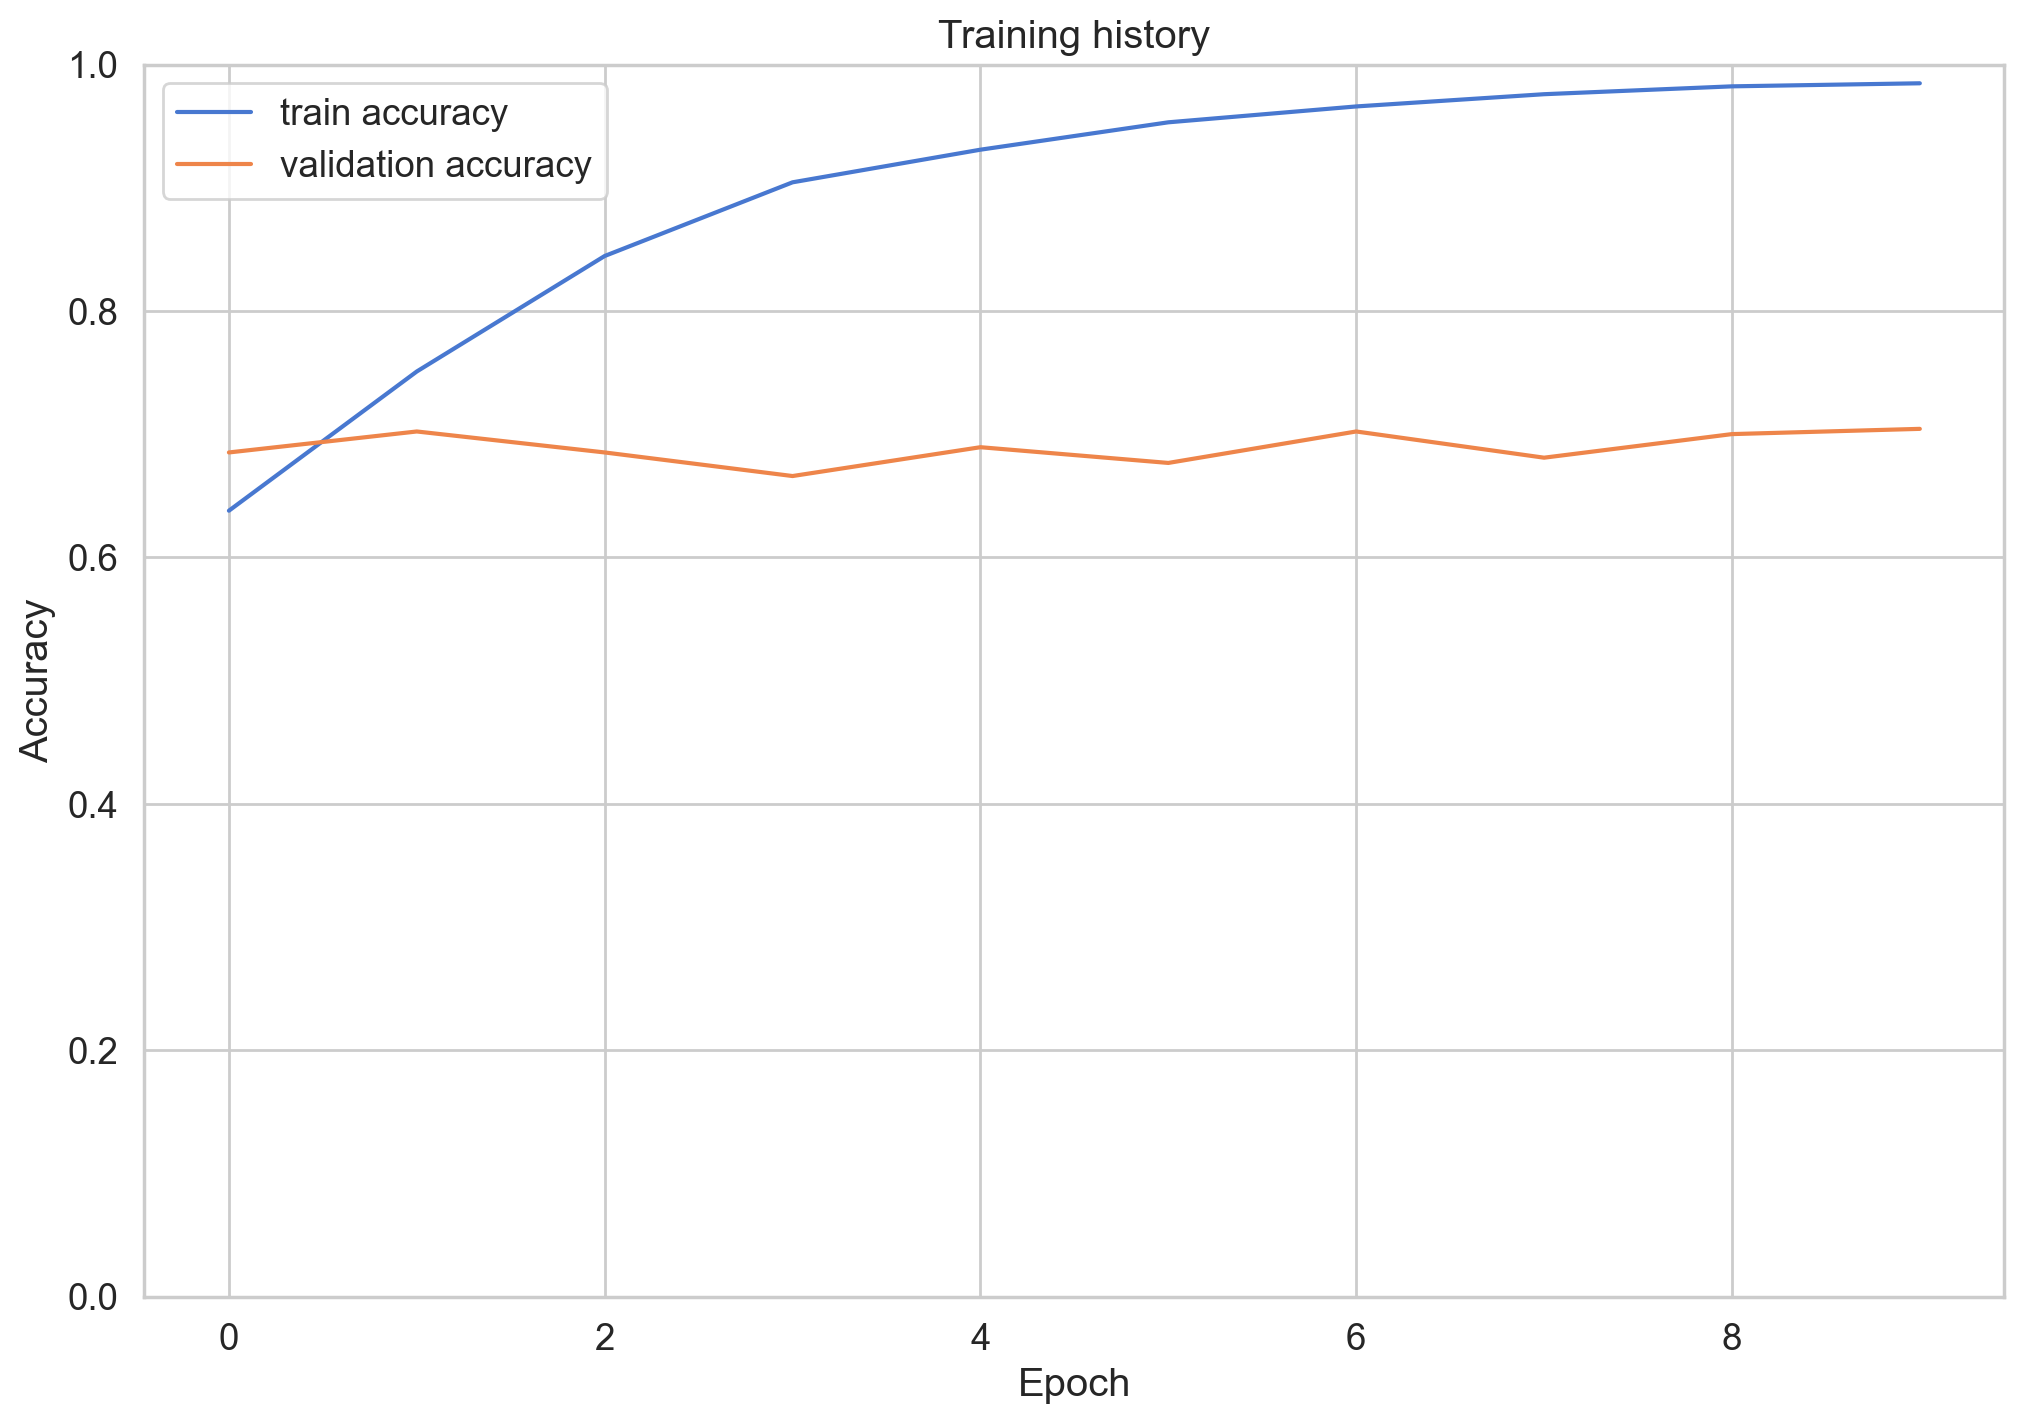

In [156]:
train_acc = [tensor.cpu().numpy() for tensor in history['train_acc']]
val_acc = [tensor.cpu().numpy() for tensor in history['val_acc']]

plt.plot(train_acc, label='train accuracy')
plt.plot(val_acc, label='validation accuracy')
plt.title('Training history')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim([0, 1])
plt.show()

A precisão do treinamento começa a se aproximar de 100% após 10 épocas ou mais. Você pode tentar ajustar os parâmetros um pouco mais, mas isso será bom o suficiente para nós.

Não quer esperar? Descomente a próxima célula para baixar meu modelo pré-treinado:

In [157]:

# !gdown --id  ==> PUT MY ID THERE1V8itWtowCYnb2Bc9KlK9SxGff9WwmogA

# model = SentimentClassifier(len(class_names))
# model.load_state_dict(torch.load('best_model_state.bin'))
# model = model.to(device)

### Avaliação

Então, quão bom é nosso modelo em prever sentimentos? Vamos começar calculando a precisão nos dados de teste:

In [158]:
test_acc, _ = eval_model(
  model,
  test_data_loader,
  loss_fn,
  device,
  len(df_test)
)

test_acc.item()

0.7127659574468085

**TODO: Adicionar mais dados para subir a acurácia**

A precisão é cerca de 1% menor no conjunto de teste. Nosso modelo parece generalizar bem.

Definiremos uma função auxiliar para obter as previsões do nosso modelo:

In [159]:

def get_predictions(model, data_loader):
  model = model.eval()

  review_texts = []
  predictions = []
  prediction_probs = []
  real_values = []

  with torch.no_grad():
    for d in data_loader:

      texts = d["review_text"]
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["targets"].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
      )
      _, preds = torch.max(outputs, dim=1)

      probs = F.softmax(outputs, dim=1)

      review_texts.extend(texts)
      predictions.extend(preds)
      prediction_probs.extend(probs)
      real_values.extend(targets)

  predictions = torch.stack(predictions).cpu()
  prediction_probs = torch.stack(prediction_probs).cpu()
  real_values = torch.stack(real_values).cpu()
  return review_texts, predictions, prediction_probs, real_values

Isso é semelhante à função de avaliação, exceto que estamos armazenando o texto das avaliações e as probabilidades previstas (aplicando o softmax nas saídas do modelo):

In [160]:
y_review_texts, y_pred, y_pred_probs, y_test = get_predictions(
  model,
  test_data_loader
)

Vamos dar uma olhada no relatório de classificação

In [161]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    negative       0.71      0.76      0.73       151
     neutral       0.68      0.64      0.66       174
    positive       0.76      0.74      0.75       145

    accuracy                           0.71       470
   macro avg       0.71      0.72      0.72       470
weighted avg       0.71      0.71      0.71       470



Parece que é realmente difícil classificar avaliações neutras (3 estrelas). E posso dizer por experiência própria, olhando muitas avaliações, que elas são difíceis de classificar.

Continuaremos com a matriz de confusão:

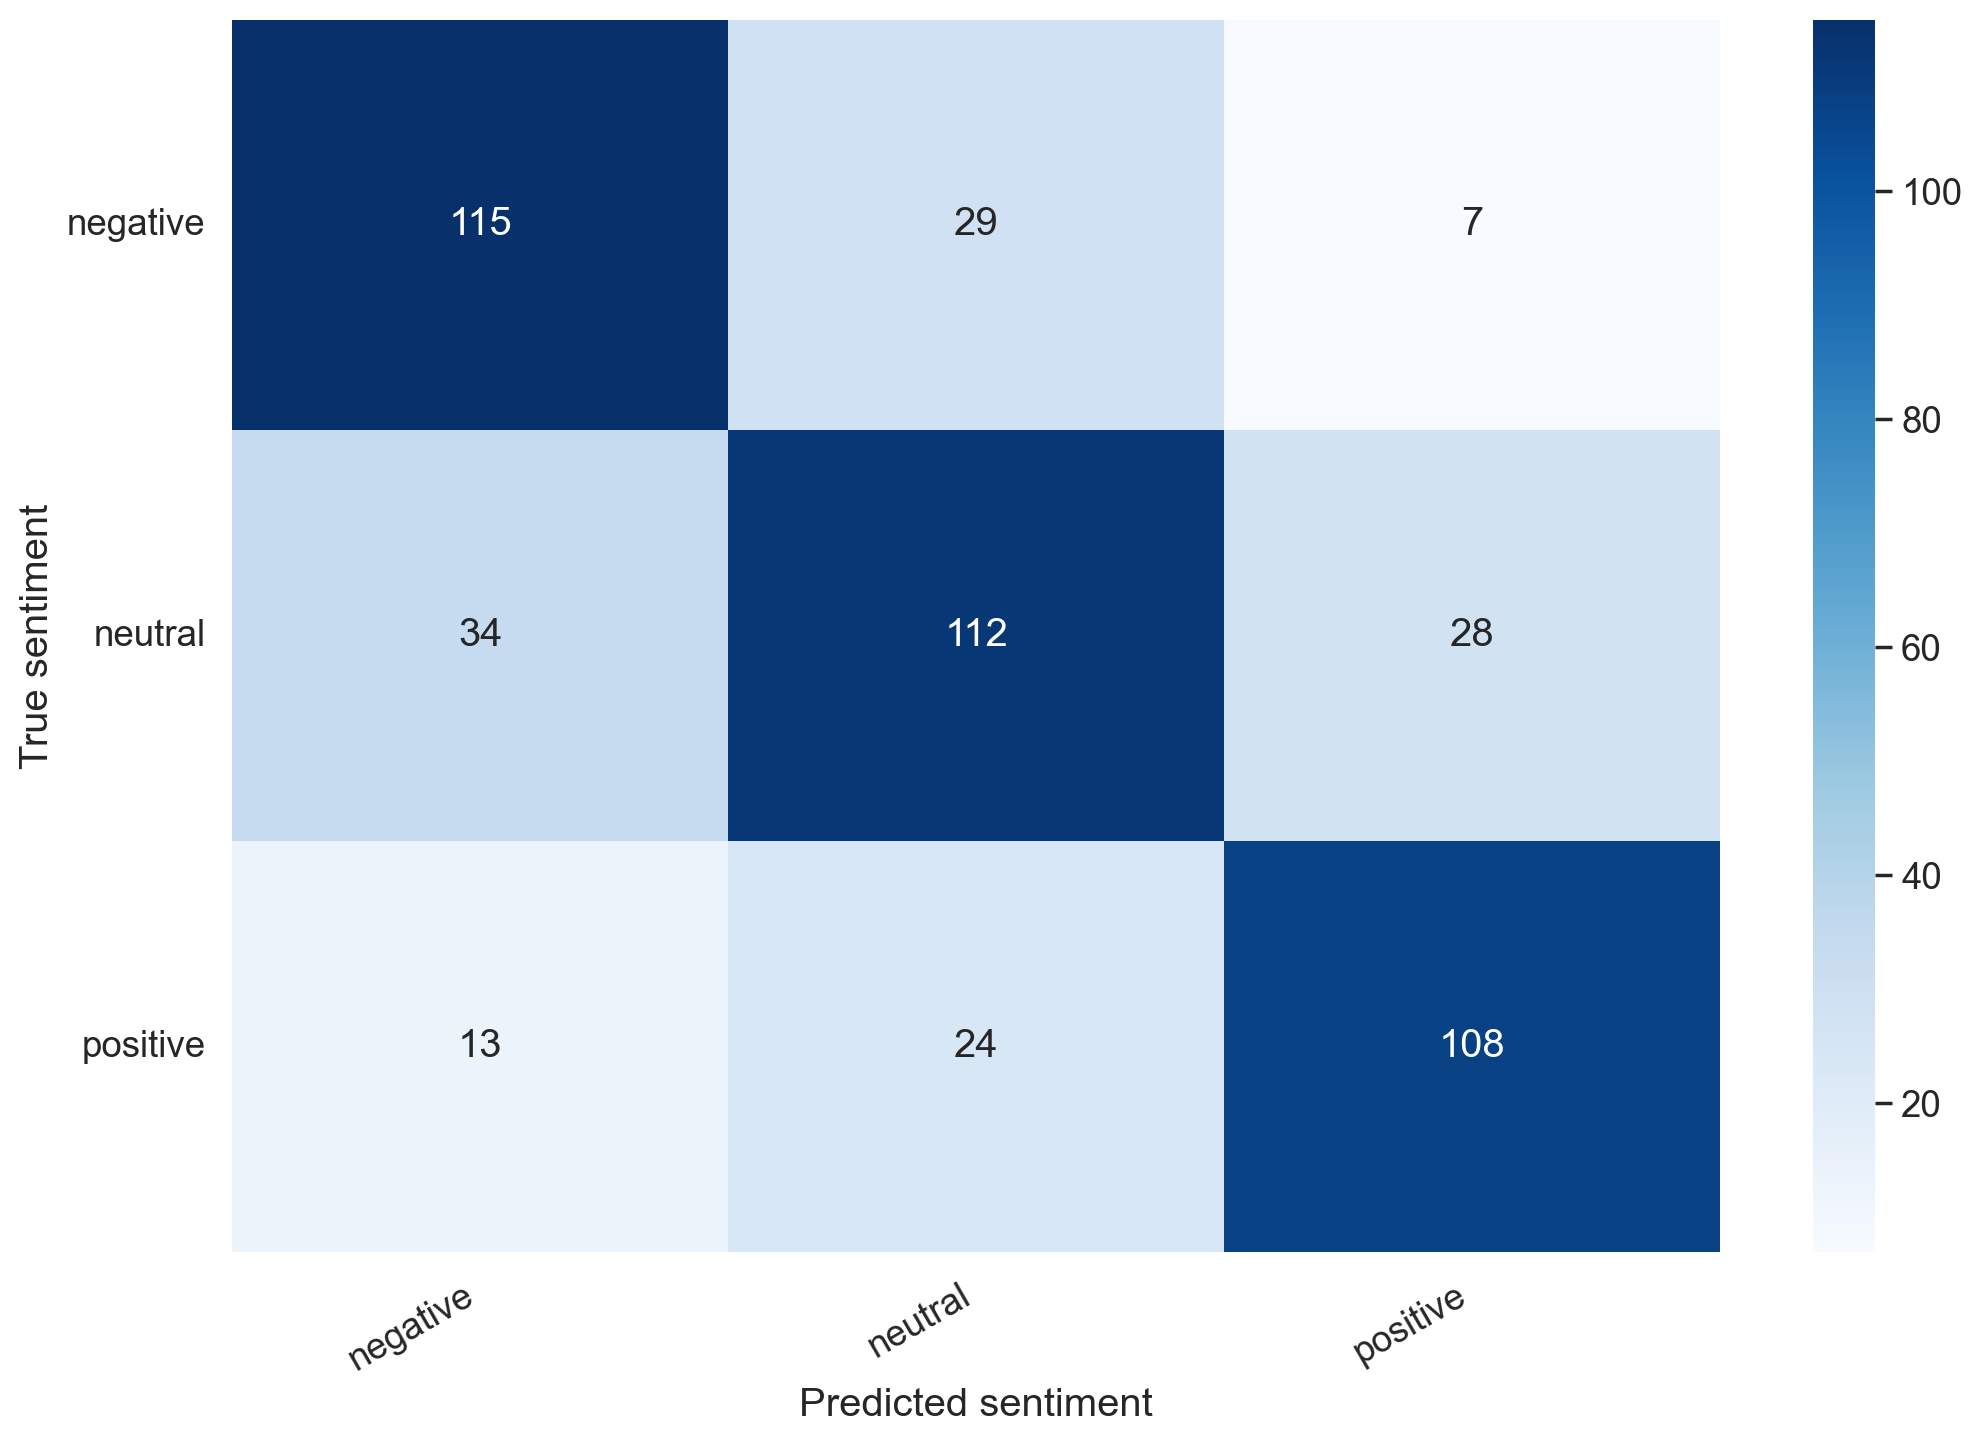

In [162]:
def show_confusion_matrix(confusion_matrix):
  hmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
  hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
  hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
  plt.ylabel('True sentiment')
  plt.xlabel('Predicted sentiment')

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
show_confusion_matrix(df_cm)

Isso confirma que nosso modelo está tendo dificuldade em classificar avaliações neutras. Ele confunde aquelas com negativas e positivas em uma frequência aproximadamente igual.

Essa é uma boa visão geral do desempenho do nosso modelo. Mas vamos dar uma olhada em um exemplo dos nossos dados de teste:

In [163]:
idx = 2

review_text = y_review_texts[idx]
true_sentiment = y_test[idx]
pred_df = pd.DataFrame({
  'class_names': class_names,
  'values': y_pred_probs[idx]
})

In [164]:
print("\n".join(wrap(review_text)))
print()
print(f'True sentiment: {class_names[true_sentiment]}')

Péssimo, fiquei mais de meia hora tentando por meus cartões de crédito
e aparecia várias mensagens diferentes. Muito ruim, não tem
assistência nenhuma para poder pedir ajuda apenas perguntas
frequentes. Não sei quem avaliou vocês como 1° porque é horrível. Te
dá um cupom mas não consegue usar porque a compra não conclui. E o
melhor que e nem dinheiro dava, sempre que colocava dinheiro aparecia
como erro.

True sentiment: negative


Agora podemos analisar a confiança de cada sentimento do nosso modelo:

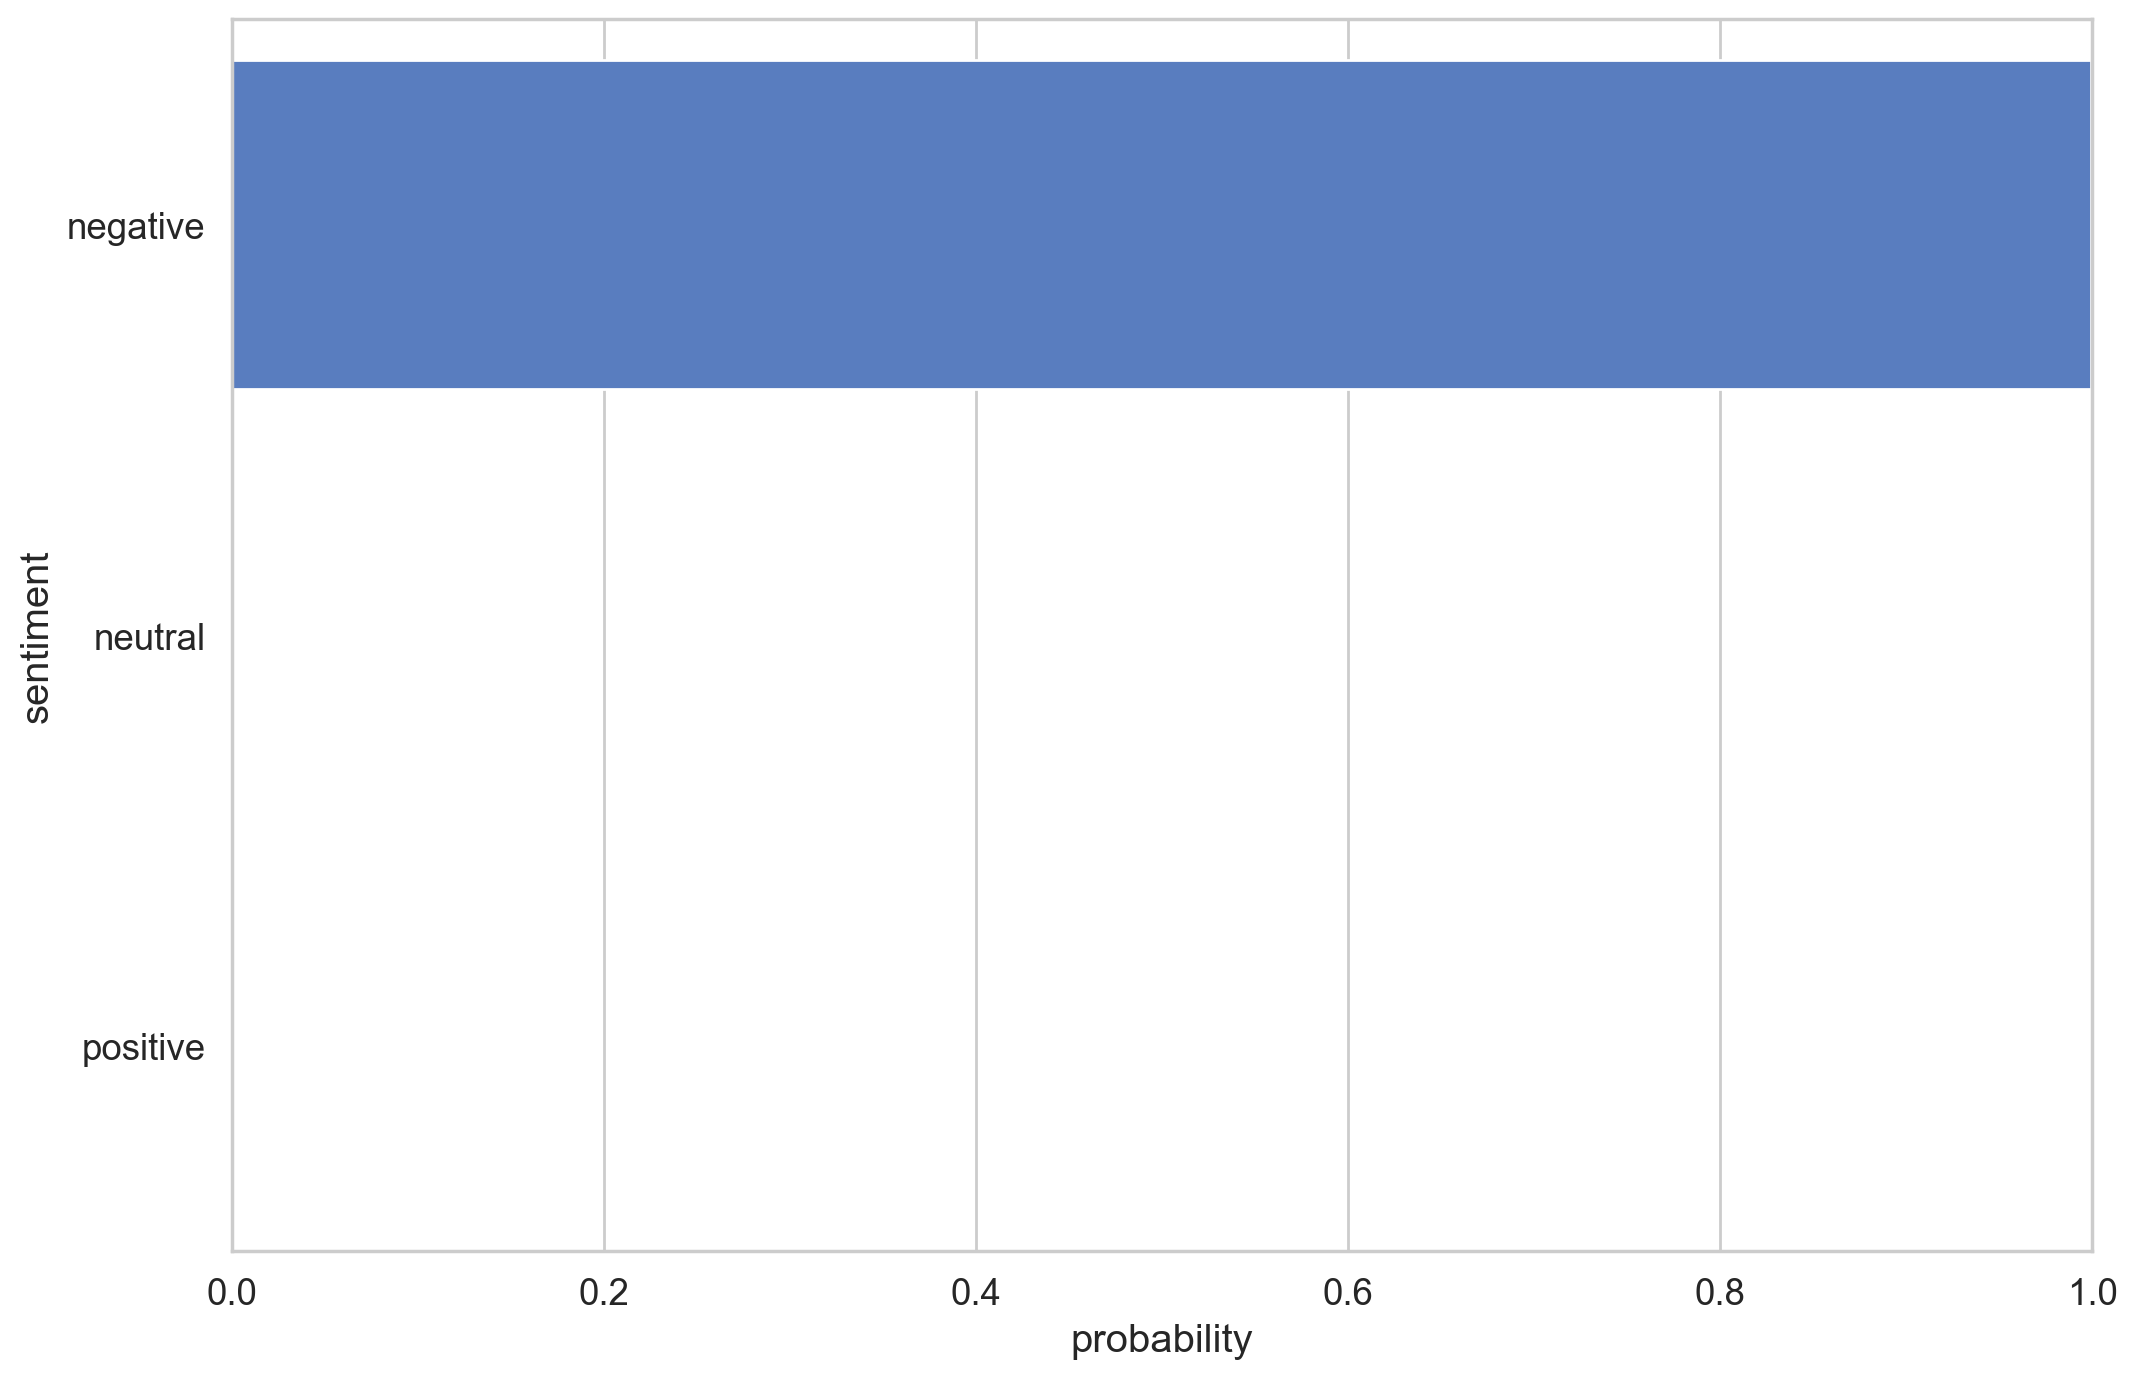

In [165]:
sns.barplot(x='values', y='class_names', data=pred_df, orient='h')
plt.ylabel('sentiment')
plt.xlabel('probability')
plt.xlim([0, 1]);

### Prevendo em texto bruto

Vamos usar nosso modelo para prever o sentimento de algum texto bruto:

Temos que usar o tokenizador para codificar o texto:

In [166]:
review_text = "Não sei dizer nada sobre o ifood."

In [167]:
encoded_review = tokenizer.encode_plus(
  review_text,
  max_length=MAX_LEN,
  add_special_tokens=True,
  return_token_type_ids=False,
  pad_to_max_length=True,
  return_attention_mask=True,
  return_tensors='pt',
)

d:\Visual Code\Classification\venv\Lib\site-packages\transformers\tokenization_utils_base.py:2700: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


Vamos obter as previsões do nosso modelo:

In [168]:
input_ids = encoded_review['input_ids'].to(device)
attention_mask = encoded_review['attention_mask'].to(device)

output = model(input_ids, attention_mask)
_, prediction = torch.max(output, dim=1)

print(f'Review text: {review_text}')
print(f'Sentiment  : {class_names[prediction]}')

Review text: Não sei dizer nada sobre o ifood.
Sentiment  : neutral
